In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('reviews_by_course.csv', encoding='latin1')

In [3]:
df.head(20)

,CourseId,Review,Label
0,2-speed-it,BOring,1
1,2-speed-it,Bravo !,5
2,2-speed-it,Very goo,5
3,2-speed-it,"Great course - I recommend it for all, especia...",5
4,2-speed-it,One of the most useful course on IT Management!,5
5,2-speed-it,I was disappointed because the name is mislead...,3
6,2-speed-it,Super content. I'll definitely re-do the course,5
7,2-speed-it,Etant contrÃ´leur de gestion pour le dÃ©partem...,5
8,2-speed-it,One of the excellent courses at Coursera for i...,5
9,2-speed-it,Is there any reason why you should not apply t...,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140320 entries, 0 to 140319
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   CourseId  140320 non-null  object
 1   Review    140317 non-null  object
 2   Label     140320 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 3.2+ MB


In [27]:
#df=df.head(80000)

drop all reviews except english

In [5]:

from langdetect import detect, DetectorFactory
import pandas as pd

DetectorFactory.seed = 0  # for reproducibility

def is_english(text):
    try:
        return detect(str(text)) == "en"
    except:
        return False

# Example: text column name = "review"
df = df[df["Review"].apply(is_english)]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107052 entries, 3 to 140319
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   CourseId  107052 non-null  object
 1   Review    107052 non-null  object
 2   Label     107052 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 3.3+ MB


In [11]:
df.isnull().sum()

CourseId    0
Review      0
Label       0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107052 entries, 3 to 140319
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   CourseId  107052 non-null  object
 1   Review    107052 non-null  object
 2   Label     107052 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 3.3+ MB


In [13]:
df.head(20)

,CourseId,Review,Label
3,2-speed-it,"Great course - I recommend it for all, especia...",5
4,2-speed-it,One of the most useful course on IT Management!,5
5,2-speed-it,I was disappointed because the name is mislead...,3
6,2-speed-it,Super content. I'll definitely re-do the course,5
8,2-speed-it,One of the excellent courses at Coursera for i...,5
9,2-speed-it,Is there any reason why you should not apply t...,5
10,2-speed-it,Excellent course and teachers. Congratulations!!,5
11,2-speed-it,This is a good course for an CIO in a non tech...,5
12,2-speed-it,"Good content, but the course setting does (at ...",3
13,2-speed-it,Very structured approach. Thank you for sharin...,5


In [32]:
df['CourseId'].nunique()

1636

In [15]:
df['Label'].unique()

array([5, 3, 4, 2, 1])

In [37]:
df["sentiment"].value_counts()

sentiment
positive    54531
neutral      2653
negative     2534
Name: count, dtype: int64

In [16]:
df["Sentiment"] = df["Label"].map({
    1: "Extremely Negative",
    2: "Negative",
    3: "Neutral",
    4: "Positive",
    5: "Extremely Positive"
})

In [36]:
df["SentimentLabel"] = df["Sentiment"].map({
    "Extremely Negative":0,
     "Negative":0,
    "Neutral":1,
    "Positive":2,
    "Extremely Positive":2
})

In [37]:
df["Sentiment"].value_counts()

Sentiment
extremely positive    79199
positive              18058
neutral                5073
extremely negative     2469
negative               2253
Name: count, dtype: int64

In [40]:
df.drop(columns=["SentimentLabel"], inplace=True)

label encoding

In [42]:
df["Sentiment"].value_counts(dropna=False)
df["Sentiment"].unique()
df["Sentiment"] = (
    df["Sentiment"]
    .astype(str)
    .str.strip()      # remove spaces
    .str.lower()      # normalize case
)
df["SentimentLabel"] = df["Sentiment"].map({
    "extremely negative": 0,
    "negative": 0,
    "neutral": 1,
    "positive": 2,
    "extremely positive": 2
})
df["SentimentLabel"].value_counts(dropna=False)

SentimentLabel
2    97257
1     5073
0     4722
Name: count, dtype: int64

In [38]:
df["SentimentLabel"].value_counts()

Series([], Name: count, dtype: int64)

In [43]:
df.head()

,CourseId,Review,Label,Sentiment,SentimentLabel
3,2-speed-it,"Great course - I recommend it for all, especia...",5,extremely positive,2
4,2-speed-it,One of the most useful course on IT Management!,5,extremely positive,2
5,2-speed-it,I was disappointed because the name is mislead...,3,neutral,1
6,2-speed-it,Super content. I'll definitely re-do the course,5,extremely positive,2
8,2-speed-it,One of the excellent courses at Coursera for i...,5,extremely positive,2


In [45]:
df.head(20)

,CourseId,Review,Label,Sentiment,SentimentLabel
3,2-speed-it,"Great course - I recommend it for all, especia...",5,extremely positive,2
4,2-speed-it,One of the most useful course on IT Management!,5,extremely positive,2
5,2-speed-it,I was disappointed because the name is mislead...,3,neutral,1
6,2-speed-it,Super content. I'll definitely re-do the course,5,extremely positive,2
8,2-speed-it,One of the excellent courses at Coursera for i...,5,extremely positive,2
9,2-speed-it,Is there any reason why you should not apply t...,5,extremely positive,2
10,2-speed-it,Excellent course and teachers. Congratulations!!,5,extremely positive,2
11,2-speed-it,This is a good course for an CIO in a non tech...,5,extremely positive,2
12,2-speed-it,"Good content, but the course setting does (at ...",3,neutral,1
13,2-speed-it,Very structured approach. Thank you for sharin...,5,extremely positive,2


In [20]:
df['Review'].value_counts().head(50)

Review
Great course!              509
Great course               237
Great!                     213
great course               189
Great                      174
Great Course               109
Great course.              101
good course                 96
Good course                 89
Great Course!               79
Very good course            71
very good course            69
Very good course.           66
very useful                 56
Awesome course              55
Thank you!                  52
Perfect!                    51
Very good course!           50
Good course!                48
very helpful                46
Very useful                 46
Amazing course!             44
Awesome course!             42
Good Course                 42
Very interesting            41
Thanks                      40
Good course.                38
Great course!!              37
Very useful!                34
cool                        34
Great!!!                    34
Amazing course              34
L

In [ ]:
from tweet_utils import process_tweet 
df['Processed_Review'] = df['Review'].apply(process_tweet)

In [ ]:
df.head()

In [63]:
df['Processed_Review'].head(10)

3        [great, cours, recommend, especi, busi, manag]
4                              [one, use, cours, manag]
5     [disappoint, name, mislead, cours, provid, goo...
6               [super, content, definit, re-do, cours]
8     [one, excel, cours, coursera, inform, technolo...
9     [reason, appli, cours, bcg, content, pretti, u...
10                   [excel, cours, teacher, congratul]
11            [good, cours, cio, non, technic, compani]
12    [good, content, cours, set, least, allow, lear...
13                   [structur, approach, thank, share]
Name: Processed_Review, dtype: object

In [ ]:
df['Review'].head(10)

In [65]:
df.isnull().sum()

CourseId            0
Review              0
Label               0
Sentiment           0
Processed_Review    0
dtype: int64

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59718 entries, 3 to 79999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CourseId          59718 non-null  object
 1   Review            59718 non-null  object
 2   Label             59718 non-null  int64 
 3   Sentiment         59718 non-null  object
 4   Processed_Review  59718 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.7+ MB


In [33]:
df['CourseId'].value_counts().head(40)

CourseId
machine-learning                          7177
learning-how-to-learn                     5864
python                                    5115
python-data                               1991
python-network-data                       1585
data-scientists-tools                     1422
html-css-javascript                       1311
ml-foundations                            1165
r-programming                             1145
grammar-punctuation                       1113
html-css-javascript-for-web-developers     997
html                                       982
food-and-health                            889
childnutrition                             881
python-databases                           796
calculus1                                  734
web-frameworks                             704
fundamentals-of-graphic-design             678
happiness                                  675
marketing-digital                          672
work-smarter-not-harder                    664
nego

display top 15 course

C:\Users\Abd Elrhman\AppData\Local\Temp\ipykernel_18492\1676930243.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


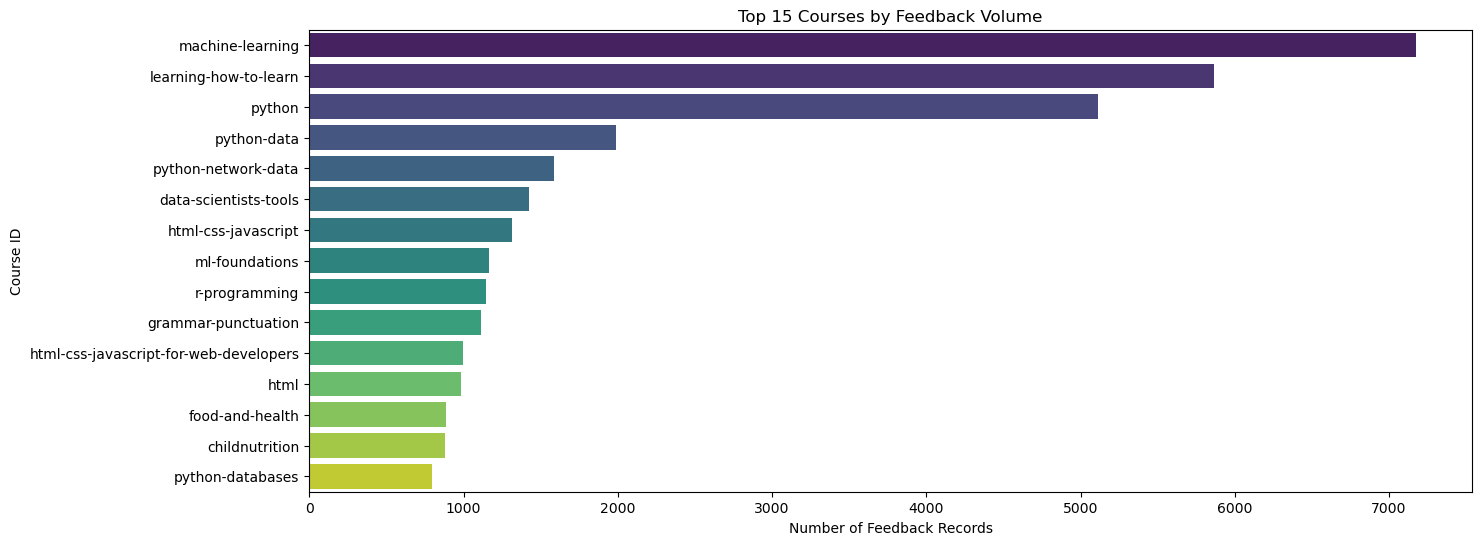

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

MIN_RECORDS = 90

# Top 15 courses by number of feedback records
top_courses = df["CourseId"].value_counts().head(15)

plt.figure(figsize=(15, 6))
sns.barplot(
    x=top_courses.values,
    y=top_courses.index,
    palette="viridis"
)
plt.title("Top 15 Courses by Feedback Volume")
plt.xlabel("Number of Feedback Records")
plt.ylabel("Course ID")
plt.show()

persentage of each sintement in all courses

C:\Users\Abd Elrhman\AppData\Local\Temp\ipykernel_18492\3031088746.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Sentiment"] = df_filtered["Sentiment"].str.lower().str.strip()


🏆 Happiest Course: parprog1
😡 Angriest Course: marketing-channels
😐 Most Neutral Course: wharton-introduction-spreadsheets-models


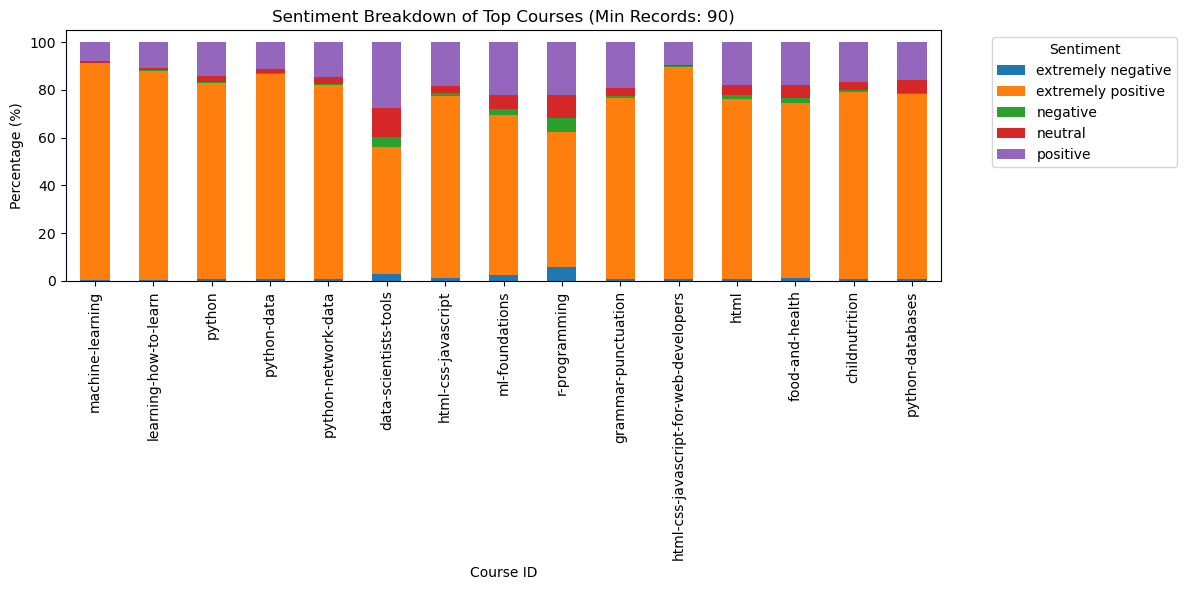

In [23]:
# ---------------------------------------------------------
# FILTER COURSES WITH ENOUGH DATA
# ---------------------------------------------------------
course_counts = df["CourseId"].value_counts()
valid_courses = course_counts[course_counts >= MIN_RECORDS].index
df_filtered = df[df["CourseId"].isin(valid_courses)]

# ---------------------------------------------------------
# SENTIMENT TABLE (values → columns)
# ---------------------------------------------------------
df_filtered["Sentiment"] = df_filtered["Sentiment"].str.lower().str.strip()

mood_table = pd.crosstab(
    df_filtered["CourseId"],
    df_filtered["Sentiment"]
)

mood_ratios = mood_table.div(mood_table.sum(axis=1), axis=0) * 100

# ---------------------------------------------------------
# FIND EXTREMES
# ---------------------------------------------------------
if "positive" in mood_ratios.columns:
    happiest = mood_ratios["positive"].idxmax()
    print(f"🏆 Happiest Course: {happiest}")

if "negative" in mood_ratios.columns:
    angriest = mood_ratios["negative"].idxmax()
    print(f"😡 Angriest Course: {angriest}")

if "neutral" in mood_ratios.columns:
    neutral = mood_ratios["neutral"].idxmax()
    print(f"😐 Most Neutral Course: {neutral}")

# ---------------------------------------------------------
# FIGURE 2: STACKED BAR (Top Courses Only)
# ---------------------------------------------------------
plot_data = mood_ratios.loc[top_courses.index]

plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title(f"Sentiment Breakdown of Top Courses (Min Records: {MIN_RECORDS})")
plt.ylabel("Percentage (%)")
plt.xlabel("Course ID")
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

positive feedback count for each course

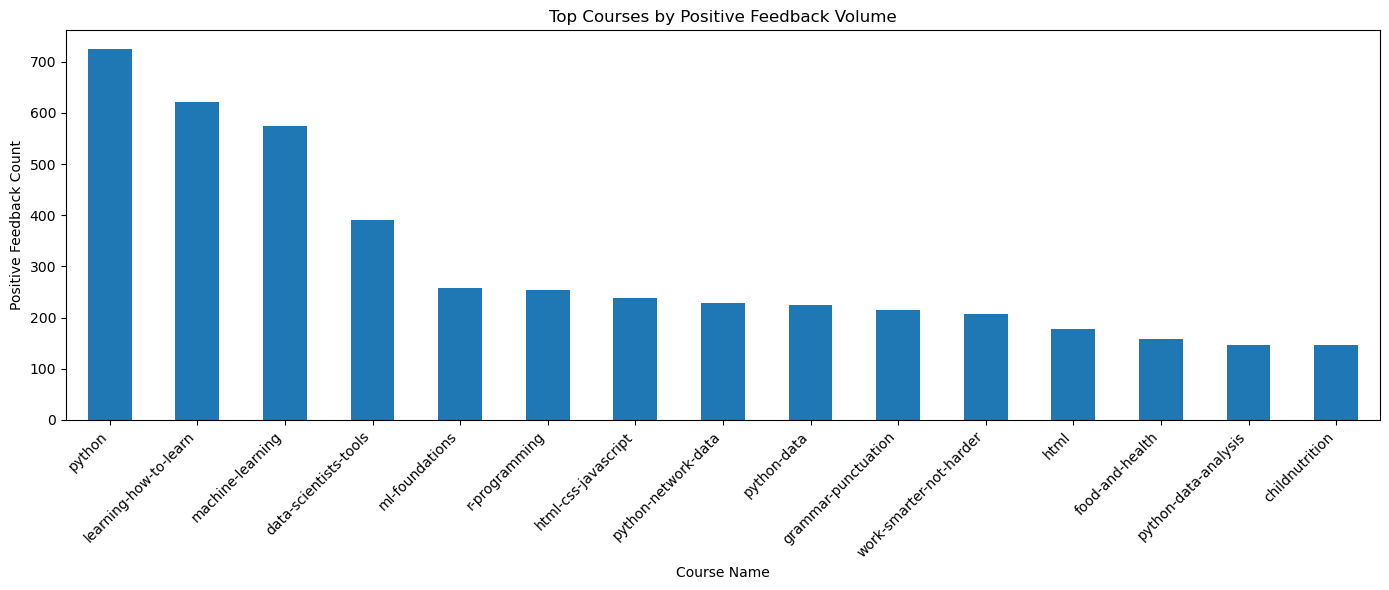

In [24]:
positive_df = df[df["Sentiment"] == "Positive"]

if positive_df.empty:
    print("❌ No positive sentiment found — check labels")
else:
    positive_counts = (
        positive_df
        .groupby("CourseId")
        .size()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(14, 6))
    positive_counts.plot(kind="bar")
    plt.ylabel("Positive Feedback Count")
    plt.xlabel("Course Name")
    plt.title("Top Courses by Positive Feedback Volume")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

positive feedback by percentage for each course

In [25]:
df["Sentiment"] = (
    df["Sentiment"]
    .astype(str)
    .str.lower()
    .str.strip()
)
total_counts = df.groupby("CourseId").size()
positive_counts = (
    df[df["Sentiment"] == "positive"]
    .groupby("CourseId")
    .size()
)
positive_percentage = (positive_counts / total_counts * 100).fillna(0)
MIN_RECORDS = 30
valid_courses = total_counts[total_counts >= MIN_RECORDS].index
positive_percentage = positive_percentage.loc[valid_courses]

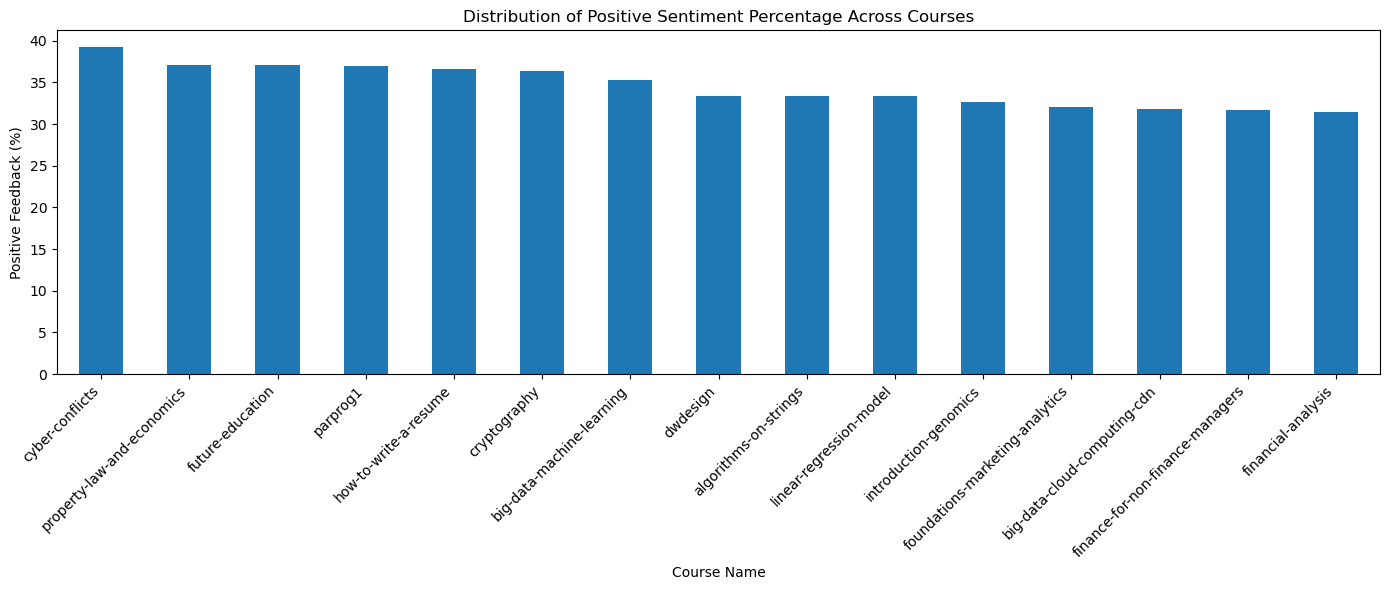

In [26]:
top_positive = positive_percentage.sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
top_positive.plot(kind="bar")
plt.ylabel("Positive Feedback (%)")
plt.xlabel("Course Name")
plt.title("Distribution of Positive Sentiment Percentage Across Courses")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

negative feedback by percentage for each course

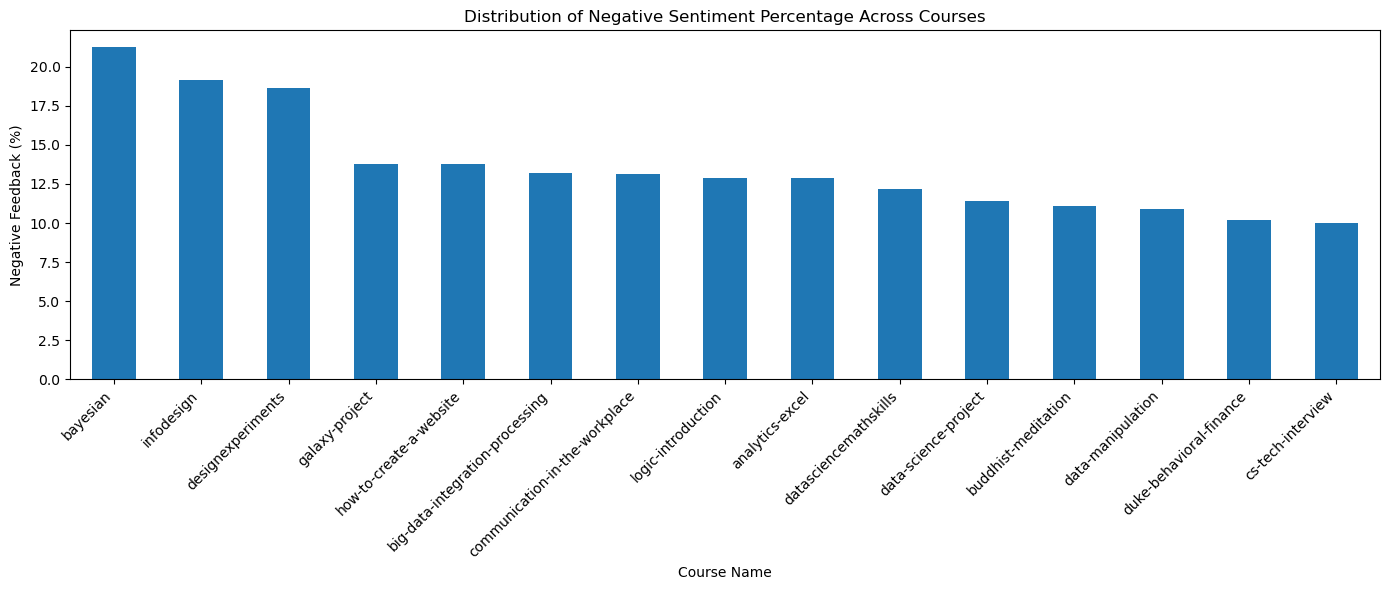

In [100]:
df["Sentiment"] = (
    df["Sentiment"]
    .astype(str)
    .str.lower()
    .str.strip()
)
total_counts = df.groupby("CourseId").size()
negative_counts = (
    df[df["Sentiment"] == "negative"]
    .groupby("CourseId")
    .size()
)
negative_percentage = (negative_counts / total_counts * 100).fillna(0)

MIN_RECORDS = 30
invalid_courses = total_counts[total_counts >= MIN_RECORDS].index
negative_percentage = negative_percentage.loc[invalid_courses]

top_negative = negative_percentage.sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
top_negative.plot(kind="bar")
plt.ylabel("Negative Feedback (%)")
plt.xlabel("Course Name")
plt.title("Distribution of Negative Sentiment Percentage Across Courses")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

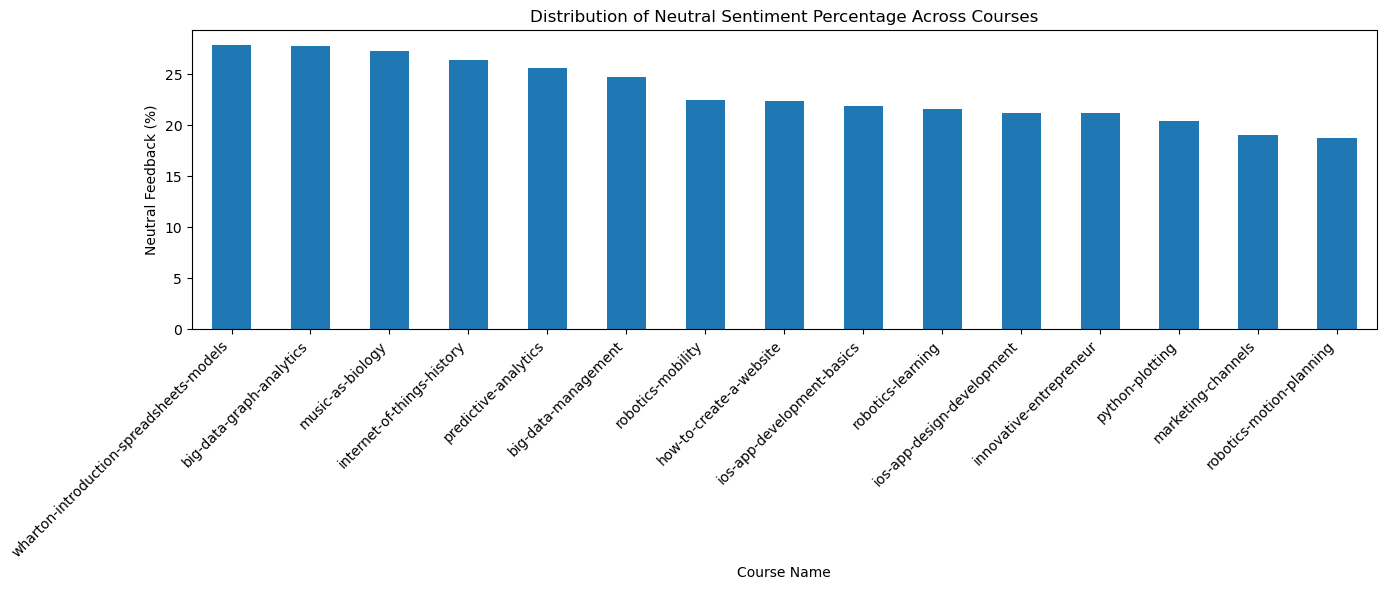

In [27]:
df["Sentiment"] = (
    df["Sentiment"]
    .astype(str)
    .str.lower()
    .str.strip()
)
total_counts = df.groupby("CourseId").size()
neutral_counts = (
    df[df["Sentiment"] == "neutral"]
    .groupby("CourseId")
    .size()
)
neutral_percentage = (neutral_counts / total_counts * 100).fillna(0)

MIN_RECORDS = 30
neutral_valid_courses = total_counts[total_counts >= MIN_RECORDS].index
neutral_percentage = neutral_percentage.loc[neutral_valid_courses]

top_neutral = neutral_percentage.sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
top_neutral.plot(kind="bar")
plt.ylabel("Neutral Feedback (%)")
plt.xlabel("Course Name")
plt.title("Distribution of Neutral Sentiment Percentage Across Courses")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Distribution of Positive, Neutral, and Negative Sentiments Across Courses

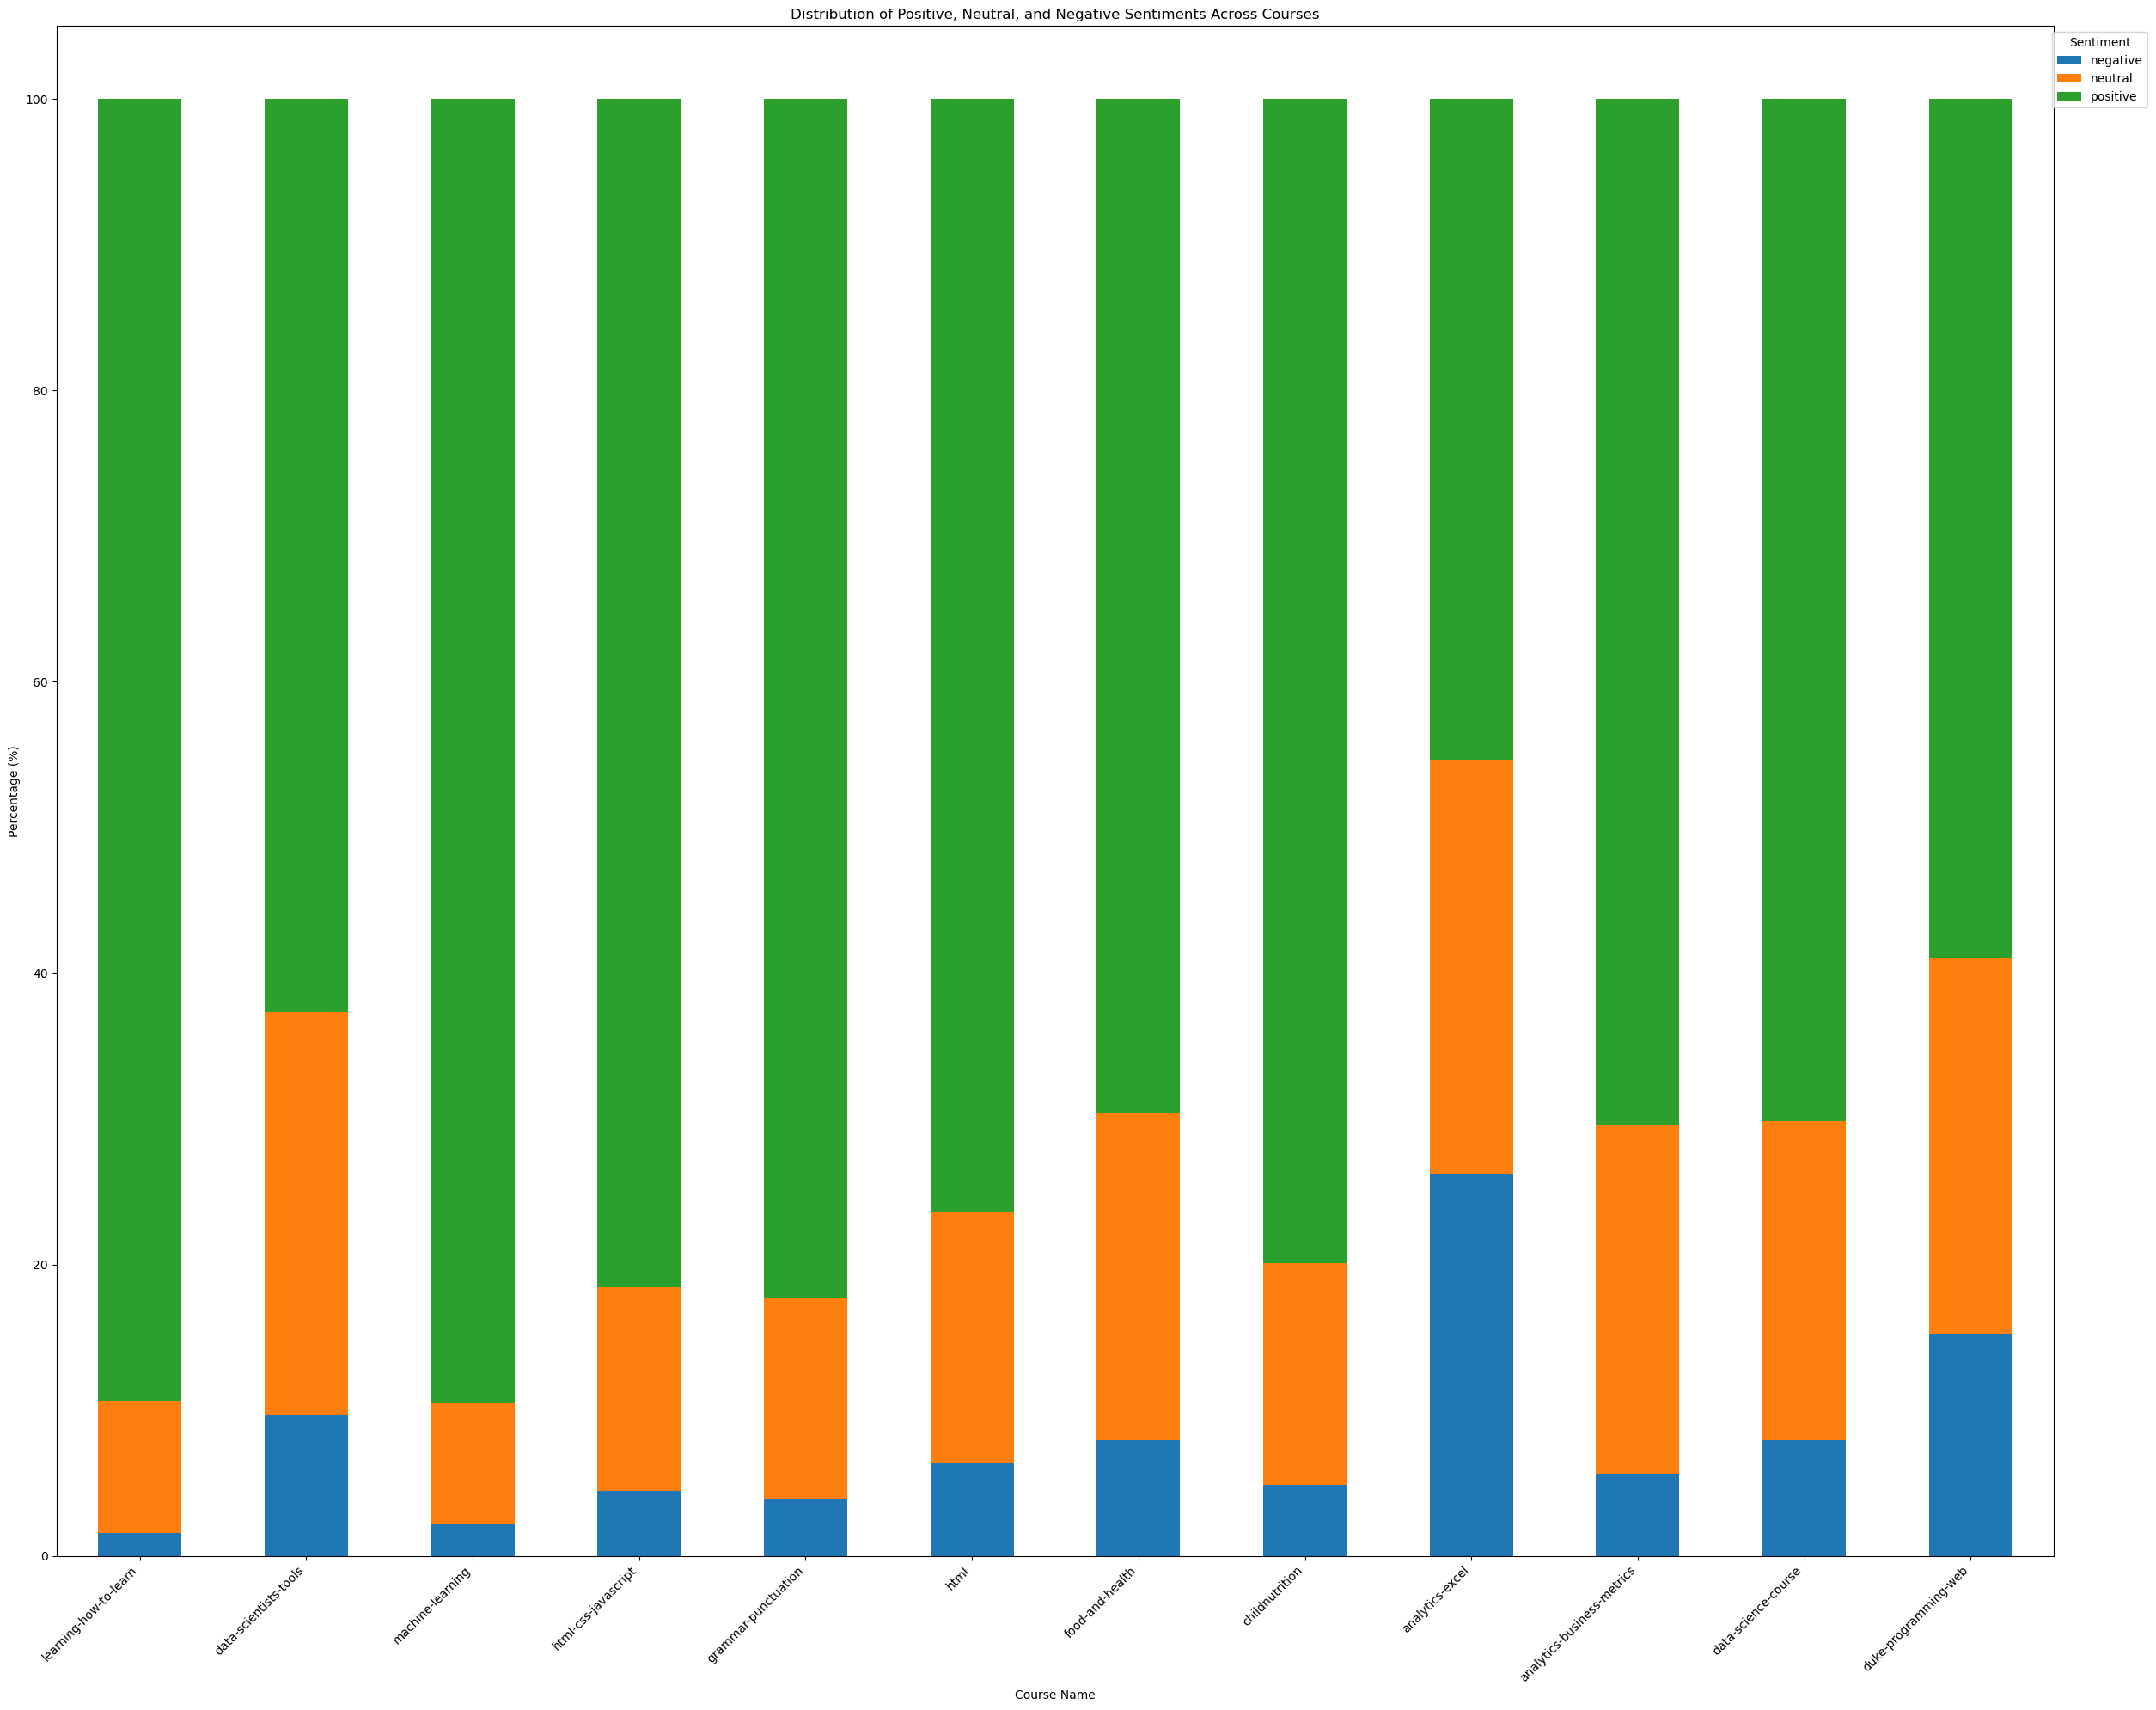

In [116]:
df["Sentiment"] = (
    df["Sentiment"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# keep ONLY the 3 required sentiments
df = df[df["Sentiment"].isin(["positive", "neutral", "negative"])]
MIN_RECORDS = 150
course_counts = df.groupby("CourseId").size()
valid_courses = course_counts[course_counts >= MIN_RECORDS].index

df_filtered = df[df["CourseId"].isin(valid_courses)]
sentiment_table = pd.crosstab(
    df_filtered["CourseId"],
    df_filtered["Sentiment"]
)
sentiment_percentage = (
    sentiment_table
    .div(sentiment_table.sum(axis=1), axis=0)
    * 100
)
top_courses = (
    course_counts.loc[valid_courses]
    .sort_values(ascending=False)
    .head(30)
    .index
)

plot_data = sentiment_percentage.loc[top_courses]
plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(25, 20)
)

plt.ylabel("Percentage (%)")
plt.xlabel("Course Name")
plt.title("Distribution of Positive, Neutral, and Negative Sentiments Across Courses")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Sentiment Distribution Across Courses

<Figure size 1200x700 with 0 Axes>

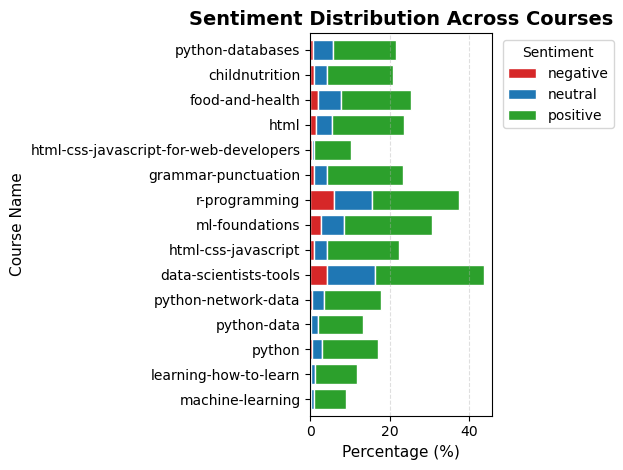

In [34]:
# Order sentiments explicitly
plot_data = plot_data[["negative", "neutral", "positive"]]

# Better colors (professional & readable)
colors = {
    "negative": "#d62728",  # red
    "neutral":  "#1f77b4",  # blue
    "positive": "#2ca02c"   # green
}

plt.figure(figsize=(12, 7))

plot_data.plot(
    kind="barh",          # horizontal = much clearer
    stacked=True,
    color=[colors[c] for c in plot_data.columns],
    edgecolor="white",
    width=0.8
)

plt.xlabel("Percentage (%)", fontsize=11)
plt.ylabel("Course Name", fontsize=11)
plt.title(
    "Sentiment Distribution Across Courses",
    fontsize=14,
    weight="bold"
)

# Clean grid
plt.grid(axis="x", linestyle="--", alpha=0.4)

# Legend outside
plt.legend(
    title="Sentiment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
en=pd.read_csv('english_reviews.csv', encoding='latin1')

percentage of negative in training and testing samples

In [2]:
from sklearn.model_selection import train_test_split
X = en['Review'].astype(str).tolist()
y = en['SentimentLabel'].tolist()

train_texts, test_texts, train_labels, test_labels = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # <--- CRITICAL STEP
)

print(f"Training samples: {len(train_texts)}")
print(f"Testing samples:  {len(test_texts)}")

neg_ratio_train = train_labels.count(0) / len(train_labels)
neg_ratio_test = test_labels.count(0) / len(test_labels)

neut_ratio_train = train_labels.count(1) / len(train_labels)
neut_ratio_test = test_labels.count(1) / len(test_labels)

print(f"\nPercentage of Negatives in Train: {neg_ratio_train:.2%}")
print(f"Percentage of Negatives in Test:  {neg_ratio_test:.2%}")

print(f"\nPercentage of Neutral in Train: {neut_ratio_train:.2%}")
print(f"Percentage of Neutral in Test:  {neut_ratio_test:.2%}")


Training samples: 85641
Testing samples:  21411

Percentage of Negatives in Train: 4.41%
Percentage of Negatives in Test:  4.41%

Percentage of Neutral in Train: 4.74%
Percentage of Neutral in Test:  4.74%


In [3]:
en.head(10)

,Unnamed: 0,CourseId,Review,Label,Sentiment,SentimentLabel
0,3,2-speed-it,"Great course - I recommend it for all, especia...",5,extremely positive,2
1,4,2-speed-it,One of the most useful course on IT Management!,5,extremely positive,2
2,5,2-speed-it,I was disappointed because the name is mislead...,3,neutral,1
3,6,2-speed-it,Super content. I'll definitely re-do the course,5,extremely positive,2
4,8,2-speed-it,One of the excellent courses at Coursera for i...,5,extremely positive,2
5,9,2-speed-it,Is there any reason why you should not apply t...,5,extremely positive,2
6,10,2-speed-it,Excellent course and teachers. Congratulations!!,5,extremely positive,2
7,11,2-speed-it,This is a good course for an CIO in a non tech...,5,extremely positive,2
8,12,2-speed-it,"Good content, but the course setting does (at ...",3,neutral,1
9,13,2-speed-it,Very structured approach. Thank you for sharin...,5,extremely positive,2


toknization

In [4]:
import torch
import numpy as np
import re
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# --- STEP 1: BUILD VOCABULARY (FROM TRAIN ONLY) ---
print("Building Vocabulary...")

def simple_tokenizer(text):
    # Lowercase & remove special chars
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) 
    return text.split()

# Count words in training set
all_words = []
for review in train_texts:
    all_words.extend(simple_tokenizer(review))

# Keep top 20,000 words
MAX_VOCAB_SIZE = 20000
word_counts = Counter(all_words)
most_common = word_counts.most_common(MAX_VOCAB_SIZE - 2)

# Create dictionary: word -> integer ID
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, _ in most_common:
    vocab[word] = len(vocab)

print(f"Vocab size: {len(vocab)}")

# --- STEP 2: VECTORIZE (TEXT -> INTEGERS) ---
print("Vectorizing text...")
MAX_LEN = 100  # Max words per review

def text_to_sequence(text, vocab, max_len):
    words = simple_tokenizer(text)
    # Map to ID, use 1 if unknown
    seq = [vocab.get(w, vocab["<UNK>"]) for w in words]
    
    # Truncate or Pad
    if len(seq) > max_len:
        seq = seq[:max_len]
    else:
        seq = seq + [vocab["<PAD>"]] * (max_len - len(seq))
    return seq

# Convert lists to Tensors
X_train_seq = [text_to_sequence(t, vocab, MAX_LEN) for t in train_texts]
X_test_seq  = [text_to_sequence(t, vocab, MAX_LEN) for t in test_texts]

train_inputs = torch.tensor(X_train_seq, dtype=torch.long)
test_inputs  = torch.tensor(X_test_seq, dtype=torch.long)

# Convert labels to Tensors
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
test_labels_tensor  = torch.tensor(test_labels, dtype=torch.long)

# --- STEP 3: WEIGHTED SAMPLER (THE IMBALANCE FIX) ---
print("Calculating weights...")

# 1. Count classes in training
class_counts = np.bincount(train_labels) # e.g. [4000, 5000, 91000]

# 2. Inverse weights (Rare classes get higher numbers)
# We add a small epsilon (1e-6) to avoid division by zero errors if a class is empty
class_weights = 1.0 / (class_counts + 1e-6)

# 3. Assign weight to every sample
sample_weights = [class_weights[label] for label in train_labels]
sample_weights = torch.DoubleTensor(sample_weights)

# 4. Create Sampler
# This will oversample the "Negative" reviews during training
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# --- STEP 4: DATALOADERS ---
BATCH_SIZE = 64

train_data = TensorDataset(train_inputs, train_labels_tensor)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=sampler)

test_data = TensorDataset(test_inputs, test_labels_tensor)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE) # No sampler for test!

print("Success: DataLoaders are ready for the model.")

Building Vocabulary...
Vocab size: 20000
Vectorizing text...
Calculating weights...
Success: DataLoaders are ready for the model.


end to end embedding

In [5]:
import torch.nn as nn

class SentimentBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super(SentimentBiLSTM, self).__init__()
        
        # 1. Embedding Layer: Converts integers (IDs) to dense vectors
        # "padding_idx=0" tells the model to ignore zeros (padding)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. LSTM Layer: The memory unit
        # bidirectional=True means it reads text Forward AND Backward
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=n_layers, 
            bidirectional=True, 
            dropout=dropout, # Dropout between LSTM layers
            batch_first=True
        )
        
        # 3. Dropout: Randomly zeros out neurons to prevent overfitting
        self.dropout = nn.Dropout(dropout)
        
        # 4. Fully Connected Layer: Maps LSTM output to 3 classes
        # Input size is hidden_dim * 2 because we have Forward + Backward states
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, text):
        # text shape: [batch_size, sent_len]
        
        # embedded shape: [batch_size, sent_len, emb_dim]
        embedded = self.embedding(text)
        
        # LSTM output
        # output shape: [batch_size, sent_len, hid_dim * 2]
        # hidden/cell shape: [n_layers * 2, batch_size, hid_dim]
        output, (hidden, cell) = self.lstm(embedded)
        
        # We concatenate the final forward hidden state and the final backward hidden state
        # hidden[-2, :, :] is the last Forward state
        # hidden[-1, :, :] is the last Backward state
        hidden_final = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        # Apply dropout
        hidden_final = self.dropout(hidden_final)
        
        # Final prediction
        return self.fc(hidden_final)

# --- CONFIGURATION ---
INPUT_DIM = len(vocab)      # Size of dictionary (approx 20,002)
EMBEDDING_DIM = 100         # Size of vector for each word
HIDDEN_DIM = 256            # Number of neurons in LSTM
OUTPUT_DIM = 3              # 3 Classes (Neg, Neu, Pos)
N_LAYERS = 2                # Number of LSTM layers stacked
DROPOUT = 0.5               # 50% dropout

# Initialize the Model
model = SentimentBiLSTM(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model created on {device}")
print(model)

Model created on cuda
SentimentBiLSTM(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)


In [6]:
import torch
print(f"PyTorch Version: {torch.version}")
print(f"CUDA Available:  {torch.cuda.is_available()}")
print(f"GPU Name:        {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch Version: <module 'torch.version' from 'C:\\ProgramData\\anaconda3\\envs\\torch-gpu\\Lib\\site-packages\\torch\\version.py'>
CUDA Available:  True
GPU Name:        NVIDIA GeForce RTX 4060 Laptop GPU


calculate (trainig loss , validation loss , training)

In [7]:
import torch.optim as optim
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F

#class FocalLoss(nn.Module):
   #def __init__(self, alpha=1, gamma=2, reduction='mean'):
    #    super(FocalLoss, self).__init__()
     #   self.alpha = alpha
      #  self.gamma = gamma
       # self.reduction = reduction

 #   def forward(self, inputs, targets):
        # Standard Cross Entropy
  #      CE_loss = F.cross_entropy(inputs, targets, reduction='none')
   #     pt = torch.exp(-CE_loss) # Probability of the correct class
    #    F_loss = self.alpha * (1-pt)*self.gamma*CE_loss
     #   if self.reduction == 'mean':
      #      return torch.mean(F_loss)
       # return torch.sum(F_loss)

#hybrid_weights = torch.tensor([1.0, 2.0, 1.0]).to(device)
# 1. SETUP OPTIMIZER & LOSS
optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-3)
criterion = nn.CrossEntropyLoss().to(device)
# Push loss function to GPU
#criterion = criterion.to(device)

# 2. HELPER FUNCTION: CALCULATE ACCURACY
def binary_accuracy(preds, y):
    # Get the index of the max probability (0, 1, or 2)
    _, predicted = torch.max(preds, 1)
    correct = (predicted == y).float() 
    acc = correct.sum() / len(correct)
    return acc

# 3. TRAIN FUNCTION (Runs once per Epoch)
def train(model, iterator, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.train() # Set to training mode (enables Dropout)
    
    for batch in iterator:
        # Get data and move to GPU
        text, labels = batch
        text = text.to(device)
        labels = labels.to(device)
        
        # Zero gradients (reset previous calculations)
        optimizer.zero_grad()
        
        # Forward pass (Prediction)
        predictions = model(text)
        
        # Calculate Loss & Accuracy
        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)
        
        # Backward pass (Calculate gradients)
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
        
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

# 4. EVALUATE FUNCTION (Checks performance on Test Set)
def evaluate(model, iterator, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.eval() # Set to evaluation mode (disables Dropout)
    
    with torch.no_grad(): # Don't calculate gradients (saves memory)
        for batch in iterator:
            text, labels = batch
            text = text.to(device)
            labels = labels.to(device)
            
            predictions = model(text)
            
            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)

            epoch_loss += loss.item()
            epoch_acc += acc.item()
        
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

# 5. THE MAIN LOOP
N_EPOCHS = 8

print(f"Starting training on {device}...")

for epoch in range(N_EPOCHS):
    
   
    # Train and Evaluate
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model, test_loader, criterion)
    best_valid_loss=1
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best-model.pt') # SAVE IT immediately
        save_msg = "--> Saved Best Model!"
    else:
        save_msg = ""
        
    
    print(f'Epoch: {epoch+1:02}')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

Starting training on cuda...
Epoch: 01
	Train Loss: 0.744 | Train Acc: 66.00%
	 Val. Loss: 0.473 |  Val. Acc: 81.66%
Epoch: 02
	Train Loss: 0.607 | Train Acc: 73.85%
	 Val. Loss: 0.352 |  Val. Acc: 85.46%
Epoch: 03
	Train Loss: 0.526 | Train Acc: 78.77%
	 Val. Loss: 0.425 |  Val. Acc: 84.72%
Epoch: 04
	Train Loss: 0.473 | Train Acc: 81.63%
	 Val. Loss: 0.398 |  Val. Acc: 85.04%
Epoch: 05
	Train Loss: 0.428 | Train Acc: 83.99%
	 Val. Loss: 0.419 |  Val. Acc: 84.12%
Epoch: 06
	Train Loss: 0.397 | Train Acc: 85.45%
	 Val. Loss: 0.395 |  Val. Acc: 84.09%
Epoch: 07
	Train Loss: 0.361 | Train Acc: 87.00%
	 Val. Loss: 0.505 |  Val. Acc: 80.15%
Epoch: 08
	Train Loss: 0.341 | Train Acc: 87.81%
	 Val. Loss: 0.441 |  Val. Acc: 83.39%


Final Report:
              precision    recall  f1-score   support

    Negative       0.42      0.62      0.50       944
     Neutral       0.19      0.58      0.29      1015
    Positive       0.99      0.86      0.92     19452

    accuracy                           0.83     21411
   macro avg       0.53      0.69      0.57     21411
weighted avg       0.92      0.83      0.87     21411



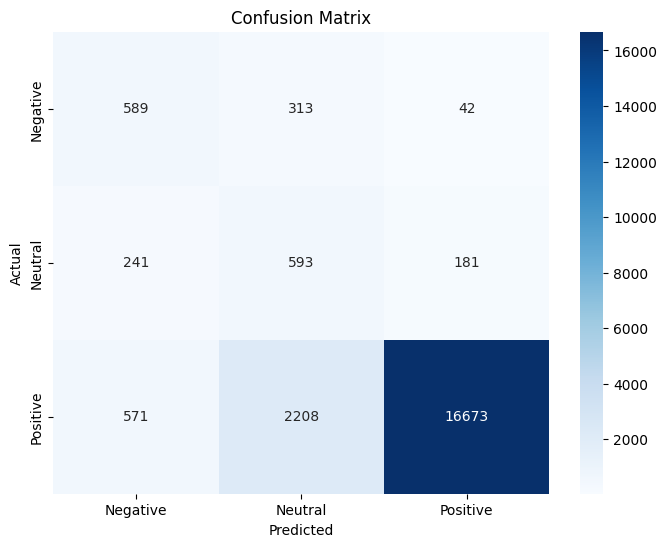

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def get_allpredictions(model, loader):
    model.eval()
    actuals = []
    predictions = []

    with torch.no_grad():
        for batch in loader:
            text, labels = batch
            text = text.to(device)
            labels = labels.to(device)

            output = model(text)

            # FIX IS HERE
            _, preds = torch.max(output, 1)

            actuals.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())

    return actuals, predictions


y_true, y_pred = get_allpredictions(model, test_loader)

print("Final Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Neutral", "Positive"]
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

In [11]:
import torch

def predict_sentiment(sentence):
    model.eval()  # 1. Switch model to "Test Mode"

#Tokenize: Convert text to words, then to numbers
#We use the same 'vocab' from your training
    tokens = [t for t in sentence.lower().split()]
    indexed = [vocab[t] for t in tokens if t in vocab]

#Safety: If the review has no known words, stop
    if len(indexed) == 0:
        print(f"Review: '{sentence}'")
        print("Error: The model doesn't know any of these words.")
        return

    # 3. Add the batch dimension (1, length) and move to GPU
    tensor = torch.LongTensor(indexed).unsqueeze(0).to(device)

#Make Prediction
    with torch.no_grad():
        output = model(tensor)                  # Get raw scores
        probs = torch.softmax(output, dim=1)    # Convert to %
        pred_idx = torch.argmax(probs).item()   # Pick the winner

#Print Results
    classes = ['Negative', 'Neutral', 'Positive']
    print(f"Review:    '{sentence}'")
    print(f"Prediction:  {classes[pred_idx]}")
    print(f"Confidence:  {probs[0][pred_idx]*100:.2f}%")
    print("-",30)

In [12]:
predict_sentiment("The instructor is amazing and very clear!")
predict_sentiment("I want my money back, this was terrible.")
predict_sentiment("The content was good but the audio was low volume.")
predict_sentiment("I am not sure if I liked it.")

Review:    'The instructor is amazing and very clear!'
Prediction:  Positive
Confidence:  72.03%
- 30
Review:    'I want my money back, this was terrible.'
Prediction:  Negative
Confidence:  62.49%
- 30
Review:    'The content was good but the audio was low volume.'
Prediction:  Neutral
Confidence:  86.63%
- 30
Review:    'I am not sure if I liked it.'
Prediction:  Neutral
Confidence:  87.05%
- 30
